In [13]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import xsdba

print(xsdba.__version__)

0.5.0


In [14]:
# --- Create toy gridded data ---
time_train = pd.date_range("1980-01-01", "1989-12-31", freq="ME")  # 10 yrs training
time_test  = pd.date_range("1980-01-01", "1999-12-31", freq="ME")  # 20 yrs test
lat = np.linspace(-10, 10, 20)   # 4 grid cells
lon = np.linspace(100, 120, 40)  # 5 grid cells

rng = np.random.default_rng(42)

# Observed training precip
obs = xr.DataArray(
    rng.gamma(shape=2, scale=2, size=(len(time_train), len(lat), len(lon))),
    coords={"time": time_train, "lat": lat, "lon": lon},
    dims=("time","lat","lon",),
    name="pr",
    attrs={"units": "mm/month"}
)
obs

# Simulated training precip (biased low)
sim = xr.DataArray(
    rng.gamma(shape=1.5, scale=1.5, size=(len(time_train), len(lat), len(lon))),
    coords={"time": time_train, "lat": lat, "lon": lon},
    dims=("time","lat","lon",),
    name="pr",
    attrs={"units": "mm/month"}
)
sim

# Simulated test data
test = xr.DataArray(
    rng.gamma(shape=1.5, scale=1.5, size=(len(time_test), len(lat), len(lon))),
    coords={"time": time_test, "lat": lat, "lon": lon},
    dims=("time","lat","lon",),
    name="pr",
    attrs={"units": "mm/month"}
)

# set the test values for 1980-1989 the same as sim
test.loc[dict(time=slice("1980-01-01", "1989-12-31"))] = sim

# Grid dimensions
nlat = len(lat)
nlon = len(lon)
n_pixels = 50

# # Generate 50 random (lat, lon) indices without replacement
# rng = np.random.default_rng(42)
# lat_idx = rng.choice(nlat, size=n_pixels, replace=True)  # can use replace=False if you want unique
# lon_idx = rng.choice(nlon, size=n_pixels, replace=True)
# na_pixels = list(zip(lat_idx, lon_idx))

# # Set those pixels to NaN for all time steps
# for i, j in na_pixels:
#     test[:, i, j] = np.nan

# Check
print(test.isnull().sum(dim="time"))
test

# Pick 5 random (lat, lon) grid cells
n_zero_var = 5
lat_idx = rng.choice(len(lat), size=n_zero_var, replace=False)
lon_idx = rng.choice(len(lon), size=n_zero_var, replace=False)
zero_var_pixels = list(zip(lat_idx, lon_idx))

# Set those pixels to constant values (zero variance across time)
for i, j in zero_var_pixels:
    const_val = float(test[:, i, j].mean().values)  # pick mean as constant
    test[:, i, j] = const_val

print("Zero-variance grid cells (lat_idx, lon_idx):", zero_var_pixels)

# Check variance over time (should be zero for chosen cells)
var_check = test.var(dim="time")
print(var_check.isel(lat=lat_idx, lon=lon_idx))

<xarray.DataArray 'pr' (lat: 20, lon: 40)> Size: 6kB
array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

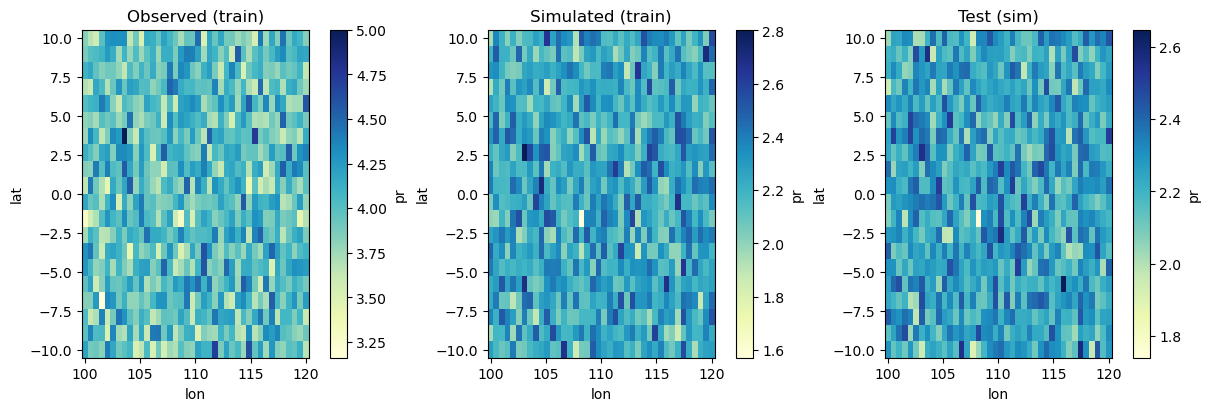

In [15]:
mean_obs = obs.groupby("time.year").mean("time", skipna=True).mean("year")
mean_sim = sim.groupby("time.year").mean("time", skipna=True).mean("year")
mean_test = test.groupby("time.year").mean("time", skipna=True).mean("year")

fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
mean_obs.plot(ax=axs[0], cmap="YlGnBu"); axs[0].set_title("Observed (train)")
mean_sim.plot(ax=axs[1], cmap="YlGnBu"); axs[1].set_title("Simulated (train)")
mean_test.plot(ax=axs[2], cmap="YlGnBu"); axs[2].set_title("Test (sim)")

plt.show()

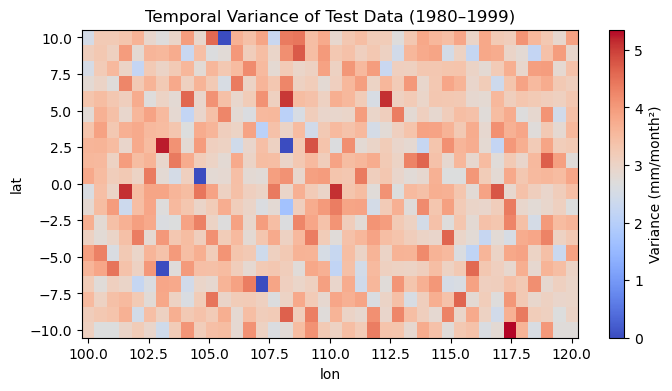

In [16]:
# Calculate variance across time
var_map = test.var(dim="time")

# Plot heatmap
plt.figure(figsize=(8, 4))
cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color="black")
var_map.plot(
    cmap=cmap,  # blue = low, red = high
    cbar_kwargs={"label": f"Variance ({test.attrs['units']}²)"}
)
plt.title("Temporal Variance of Test Data (1980–1999)")
plt.show()

In [17]:
# --- Fit QDM ---
qdm = xsdba.adjustment.QuantileDeltaMapping.train(obs, sim, nquantiles=10, kind="*", group="time.month")

In [48]:
# --- Adjust test data with fitted QDM ---
adjTest = qdm.adjust(test, extrapolation="constant", interp="cubic")

/home/dafcluster4/miniconda3/envs/xclim_stable/lib/python3.13/site-packages/xsdba/utils.py:399: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(


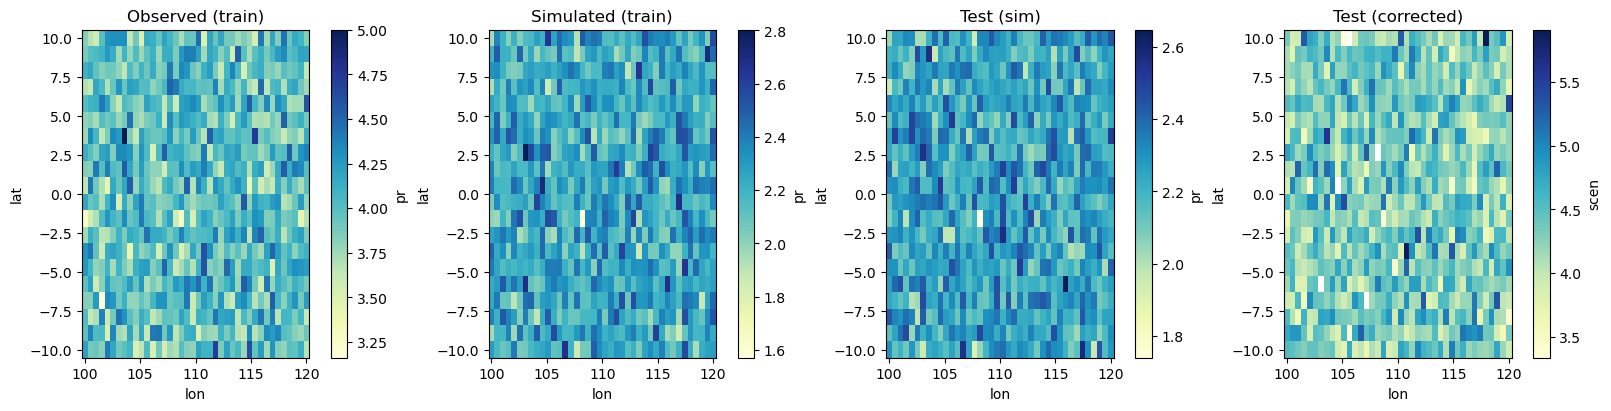

In [49]:
mean_corrected = adjTest.groupby("time.month").mean("time", skipna=True).mean("month")
fig, axs = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
mean_obs.plot(ax=axs[0], cmap="YlGnBu"); axs[0].set_title("Observed (train)")
mean_sim.plot(ax=axs[1], cmap="YlGnBu"); axs[1].set_title("Simulated (train)")
mean_test.plot(ax=axs[2], cmap="YlGnBu"); axs[2].set_title("Test (sim)")
mean_corrected.plot(ax=axs[3], cmap="YlGnBu"); axs[3].set_title("Test (corrected)")
plt.show()

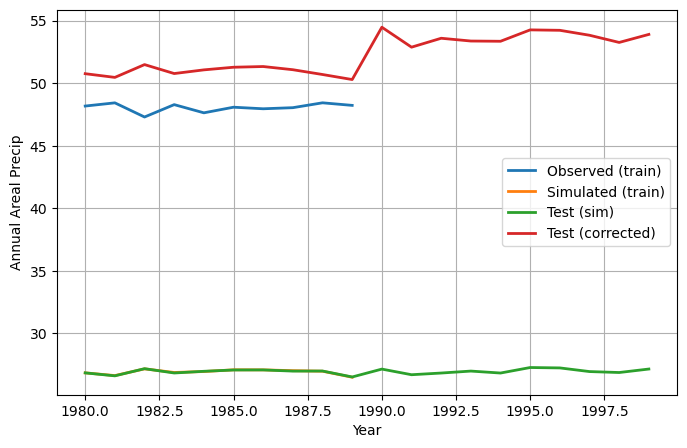

In [50]:
# --- Areal average time series ---
obs_area = obs.mean(["lat","lon"]).groupby("time.year").sum("time")
sim_area = sim.mean(["lat","lon"]).groupby("time.year").sum("time")
test_area = test.mean(["lat","lon"]).groupby("time.year").sum("time")
corrected_area = adjTest.mean(["lat","lon"]).groupby("time.year").sum("time")

fig2, ax2 = plt.subplots(figsize=(8,5))
ax2.plot(obs_area["year"], obs_area, label="Observed (train)", lw=2)
ax2.plot(sim_area["year"], sim_area, label="Simulated (train)", lw=2)
ax2.plot(test_area["year"], test_area, label="Test (sim)", lw=2)
ax2.plot(corrected_area["year"], corrected_area, label="Test (corrected)", lw=2)
ax2.set_ylabel("Annual Areal Precip")
ax2.set_xlabel("Year")
ax2.legend()
ax2.grid(True)
plt.show()

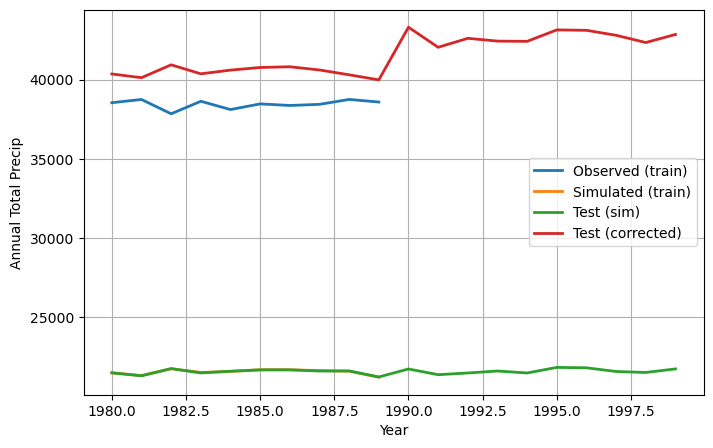

In [51]:
# --- Areal total time series ---
obs_area = obs.sum(["lat","lon"]).groupby("time.year").sum("time")
sim_area = sim.sum(["lat","lon"]).groupby("time.year").sum("time")
test_area = test.sum(["lat","lon"]).groupby("time.year").sum("time")
corrected_area = adjTest.sum(["lat","lon"]).groupby("time.year").sum("time")

fig3, ax3 = plt.subplots(figsize=(8,5))
ax3.plot(obs_area["year"], obs_area, label="Observed (train)", lw=2)
ax3.plot(sim_area["year"], sim_area, label="Simulated (train)", lw=2)
ax3.plot(test_area["year"], test_area, label="Test (sim)", lw=2)
ax3.plot(corrected_area["year"], corrected_area, label="Test (corrected)", lw=2)
ax3.set_ylabel("Annual Total Precip")
ax3.set_xlabel("Year")
ax3.legend()
ax3.grid(True)
plt.show()

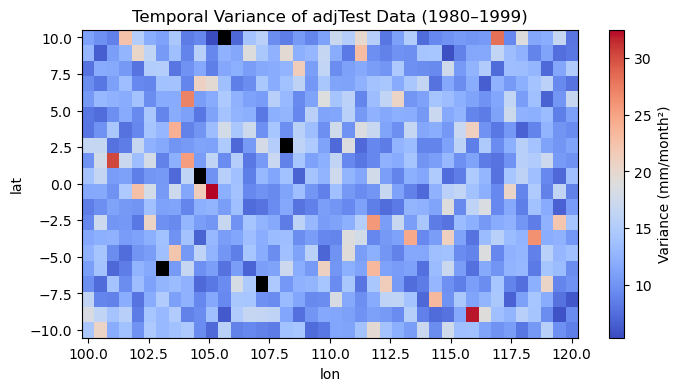

In [52]:
# Calculate variance across time
var_map = adjTest.var(dim="time")

# Make a copy of the colormap and set NaN (bad) cells to black
cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color="black")

# Plot heatmap
plt.figure(figsize=(8, 4))
var_map.plot(
    cmap=cmap,
    cbar_kwargs={"label": f"Variance ({test.attrs['units']}²)"}
)
plt.title("Temporal Variance of adjTest Data (1980–1999)")
plt.show()